In [1]:
import pandas as pd
# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
data = pd.read_csv('./merged_data.csv', low_memory=False)
data

,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-13.0,-61.0,5.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.000000000,2.0
1,-20.0,-69.0,-3.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.031249920,2.0
2,-31.0,-78.0,-15.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.062500096,2.0
3,-47.0,-65.0,-38.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.093750016,2.0
4,-67.0,-57.0,-53.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.124999936,2.0
...,...,...,...,...,...,...,...,...,...
11509046,-16.0,-56.0,24.0,3.386070,88.37,33.77,F5,2020-07-23 17:28:59.875000064,2.0
11509047,-8.0,-50.0,27.0,3.386070,88.37,33.77,F5,2020-07-23 17:28:59.906249984,2.0
11509048,-28.0,-36.0,28.0,3.386070,88.37,33.77,F5,2020-07-23 17:28:59.937499904,2.0
11509049,-29.0,-29.0,30.0,3.386070,88.37,33.77,F5,2020-07-23 17:28:59.968750080,2.0


In [3]:
data.isnull().sum()

X           0
Y           0
Z           0
EDA         0
HR          0
TEMP        0
id          0
datetime    0
label       0
dtype: int64

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11509051 entries, 0 to 11509050
Data columns (total 9 columns):
 #   Column    Dtype  
---  ------    -----  
 0   X         float64
 1   Y         float64
 2   Z         float64
 3   EDA       float64
 4   HR        float64
 5   TEMP      float64
 6   id        object 
 7   datetime  object 
 8   label     float64
dtypes: float64(7), object(2)
memory usage: 790.3+ MB


In [5]:
new_data = data.drop(columns=["id", "datetime"])

In [6]:
x = new_data.drop(columns=["label"])
y = new_data["label"]

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)

In [11]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## XGBoost

In [13]:
# train xgboost
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(x_train, y_train)

# evaluate
from sklearn.metrics import accuracy_score

# get f1_score
y_pred = model.predict(x_test)


0.9089412640742441

In [14]:
# f1 score from sklearn
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)

0.9041215350684324


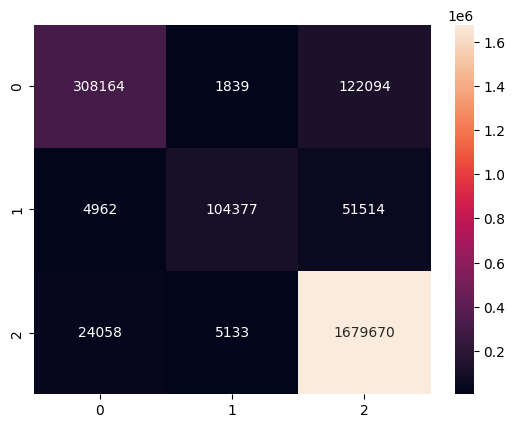

In [15]:
# Draw confuion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

In [14]:
# train keras model
import keras

model = keras.Sequential()
model.add(keras.layers.Input(shape=(x_train.shape[1],)))
model.add(keras.layers.Dense(512))
model.add(keras.layers.LeakyReLU())
model.add(keras.layers.Dense(256))
model.add(keras.layers.LeakyReLU())
model.add(keras.layers.Dense(128))
model.add(keras.layers.LeakyReLU())
model.add(keras.layers.Dense(64))
model.add(keras.layers.LeakyReLU())
model.add(keras.layers.Dense(32))
model.add(keras.layers.LeakyReLU())
model.add(keras.layers.Dense(3, activation="softmax"))

optimizer = keras.optimizers.Adam()
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

early_stopping_callback = keras.callbacks.EarlyStopping(patience=10, monitor="val_loss", min_delta=0.001)
reduce_lr_callback = keras.callbacks.ReduceLROnPlateau(patience=7, monitor="val_loss", factor=0.2)

model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.2, callbacks=[early_stopping_callback, reduce_lr_callback])

Epoch 1/5
57546/57546 ━━━━━━━━━━━━━━━━━━━━ 230s 4ms/step - accuracy: 0.8306 - loss: 0.4408 - val_accuracy: 0.8647 - val_loss: 0.3543 - learning_rate: 0.0010
Epoch 2/5
57546/57546 ━━━━━━━━━━━━━━━━━━━━ 232s 4ms/step - accuracy: 0.8885 - loss: 0.2957 - val_accuracy: 0.8971 - val_loss: 0.2730 - learning_rate: 0.0010
Epoch 3/5
57546/57546 ━━━━━━━━━━━━━━━━━━━━ 231s 4ms/step - accuracy: 0.9025 - loss: 0.2616 - val_accuracy: 0.9023 - val_loss: 0.2603 - learning_rate: 0.0010
Epoch 4/5
57546/57546 ━━━━━━━━━━━━━━━━━━━━ 233s 4ms/step - accuracy: 0.9104 - loss: 0.2421 - val_accuracy: 0.9173 - val_loss: 0.2260 - learning_rate: 0.0010
Epoch 5/5
57546/57546 ━━━━━━━━━━━━━━━━━━━━ 229s 4ms/step - accuracy: 0.9156 - loss: 0.2287 - val_accuracy: 0.9186 - val_loss: 0.2224 - learning_rate: 0.0010


In [26]:
from sklearn.metrics import f1_score
import numpy as np
y_pred = np.argmax(model.predict(x_test), axis=-1)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)

71932/71932 ━━━━━━━━━━━━━━━━━━━━ 41s 575us/step
0.8829540037708313
